<a href="https://colab.research.google.com/github/patriciadn/Ejercicospython/blob/main/minimoscuadrados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
url = "https://raw.githubusercontent.com/mike1502/THC/main/Python/Aplicaciones/MinimosCuadrados/MinimosCuadrados.csv"
df = pd.read_csv(url)  # si usas ; como separador: pd.read_csv(url, delimiter=";")
x = df["x"].to_numpy()
y = df["y"].to_numpy()
print(x)
print(y)

# Datos obtenidos de
# K.F. Riley, M. P. Hobson, S. J. Bence, 2006
# Mathematical Methods for Physics and Engineering.
# Cambridge University Press, 3rd Edition, 1363.

[1.85 2.72 2.81 3.06 3.42 3.76 4.31 4.47 4.64 4.99]
[2.26 3.1  3.8  4.11 4.74 4.31 5.24 4.03 5.69 6.57]


1.1091488253986432 0.38873678208868867


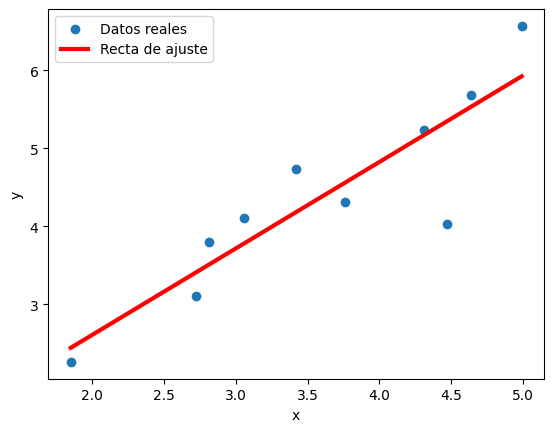

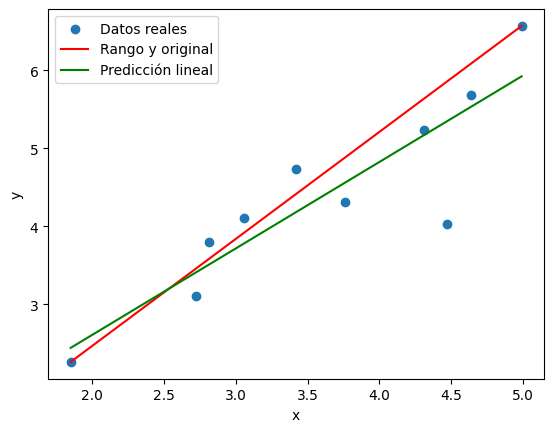

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
url = "https://raw.githubusercontent.com/mike1502/THC/main/Python/Aplicaciones/MinimosCuadrados/MinimosCuadrados.csv"
df = pd.read_csv(url)
x = df["x"].to_numpy()
y = df["y"].to_numpy()
n=len(x)
m=(n*np.sum(x*y)-np.sum(x)*np.sum(y))/(n*np.sum(x**2)-np.sum(x)**2)
b=(np.sum(y)-m*np.sum(x))/n
print(m,b)
y_pred=m*x+b


plt.scatter(x,y, label='Datos reales')
plt.plot([min(x),max(x)],[min(y_pred),max(y_pred)],color='red', label='Recta de ajuste', linewidth=3)
plt.ylabel('y')
plt.legend()
plt.show()


plt.scatter(x,y, label='Datos reales')
plt.plot([min(x),max(x)],[min(y),max(y)],color='red', label='Rango y original')
plt.plot(x,y_pred,color='green', label='Predicción lineal')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

1.1091488253986432 0.38873678208868867
Pendiente (m)= 1.1091488253986432
Ordenada al origen (b)= 0.38873678208868867
[2.44066211 3.40562159 3.50544498 3.78273219 4.18202576 4.55913637
 5.16916822 5.34663203 5.53518733 5.92338942]

Residuos [-0.18066211 -0.30562159  0.29455502  0.32726781  0.55797424 -0.24913637
  0.07083178 -1.31663203  0.15481267  0.64661058]

Error Relativo (%): (<module 'numpy' from '/usr/local/lib/python3.12/dist-packages/numpy/__init__.py'>, array([ 7.99389863,  9.85876088,  7.75144786,  7.96272049, 11.77160833,
        5.78042612,  1.35175154, 32.67077002,  2.72078503,  9.84186574]))
n media= 4.385
Var= 0.3592404573477115

Desviación Estándar= 0.5993667135800181


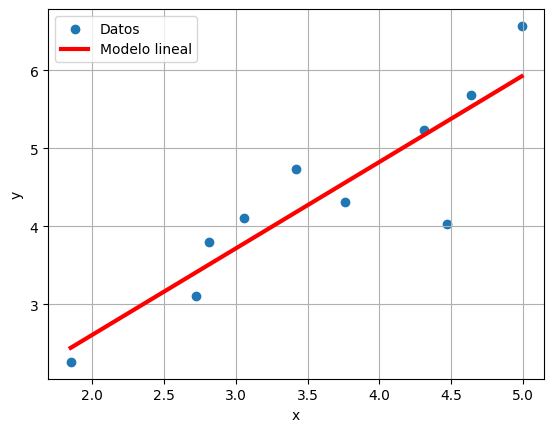

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
url = "https://raw.githubusercontent.com/mike1502/THC/main/Python/Aplicaciones/MinimosCuadrados/MinimosCuadrados.csv"
df = pd.read_csv(url)
x = df["x"].to_numpy()
y = df["y"].to_numpy()
n=len(x)
sum_x=np.sum(x)
sum_y=np.sum(y)
sum_xy=np.sum(x*y)
sum_x2=np.sum(x**2)
m=(n*np.sum(x*y)-np.sum(x)*np.sum(y))/(n*np.sum(x**2)-np.sum(x)**2)
b=(np.sum(y)-m*np.sum(x))/n
print(m,b)
print("Pendiente (m)=",m)
print("Ordenada al origen (b)=",b)
ymodel=m*x+b
print(ymodel)
res=y-ymodel
er=np,abs(res/y)*100
print("\nResiduos", res)
print("\nError Relativo (%):",er)
media=np.mean(y)
Var=np.sum(res**2)/(n-2)
de=np.sqrt(Var)
print("n media=", media)
print("Var=", Var)
print("\nDesviación Estándar=", de)
xline=np.linspace(min(x),max(x),100)
yline=m*xline+b
plt.scatter(x,y, label='Datos')
plt.plot(xline,yline,color='red', label='Modelo lineal', linewidth=3)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.show()


Modelo obtenido:
y = -0.0057x^2 + 1.1491x + 0.3241


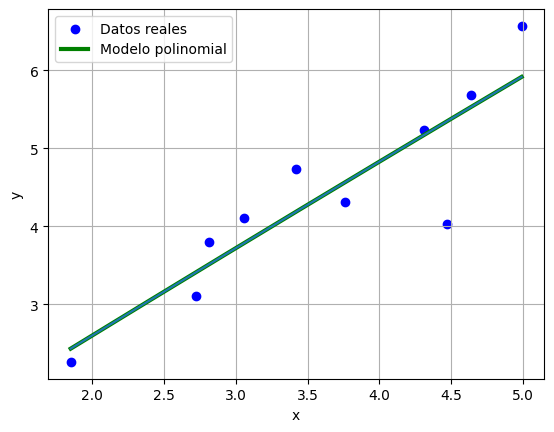

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


x =df["x"].to_numpy()
y =df["y"].to_numpy()

x = x.reshape(-1,1)

# ----------------------------
# Modelo polinomial grado 2
# ----------------------------
poly = PolynomialFeatures(degree=2, include_bias=True)
X_poly = poly.fit_transform(x)

model = LinearRegression()
model.fit(X_poly, y)

# ----------------------------
# Obtener coeficientes
# ----------------------------
c = model.intercept_
a, b = model.coef_[2], model.coef_[1]

print("Modelo obtenido:")
print(f"y = {a:.4f}x^2 + {b:.4f}x + {c:.4f}")


x_fit = np.linspace(min(x), max(x), 300).reshape(-1,1)
y_fit = model.predict(poly.transform(x_fit))

# ----------------------------
# Gráfica final
# ----------------------------
plt.scatter(x, y, label="Datos reales", color="blue")
plt.plot(x_fit, y_fit, label="Modelo polinomial", color="green", linewidth=3)
yfinal=model.predict(poly.transform(x_fit))
plt.plot(x_fit,yfinal)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()